# CIFAR-10 Classifier Feature UMAP and t-SNE

Load a trained cross-entropy classifier, extract test-set embeddings from the encoder, and visualize them with UMAP and t-SNE.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import torch
import umap
import yaml
from sklearn.manifold import TSNE

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

from src.data.cifar10 import get_cifar10_loaders
from src.models.resnet import CifarResNetClassifier
from src.training.contrastive import knn_accuracy


/w/20252/wjcai/uq/manygp/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
CONFIG_PATH = REPO_ROOT / "configs" / "cifar10_classifier.yaml"
CHECKPOINT_DIR = REPO_ROOT / "checkpoints"

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("checkpoint dir:", CHECKPOINT_DIR)

device: cpu
checkpoint dir: /w/20252/wjcai/uq/manygp/checkpoints


In [3]:
def load_best_checkpoint(checkpoint_dir: Path, device: torch.device):
    checkpoint_paths = sorted(checkpoint_dir.glob("cifar10_classifier*.pt"))
    if not checkpoint_paths:
        raise FileNotFoundError(f"No classifier checkpoint files found in {checkpoint_dir}")

    best_checkpoint = None
    best_path = None
    best_score = float("-inf")

    for checkpoint_path in checkpoint_paths:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        score = checkpoint.get("val_accuracy")
        if score is None:
            continue
        if score > best_score:
            best_score = score
            best_checkpoint = checkpoint
            best_path = checkpoint_path

    if best_checkpoint is None or best_path is None:
        raise ValueError(f"No classifier checkpoints with 'val_accuracy' found in {checkpoint_dir}")

    return best_path, best_checkpoint


BEST_CHECKPOINT_PATH, checkpoint = load_best_checkpoint(CHECKPOINT_DIR, device)
print("best checkpoint:", BEST_CHECKPOINT_PATH)
print("best stored val accuracy:", checkpoint.get("val_accuracy"))

best checkpoint: /w/20252/wjcai/uq/manygp/checkpoints/cifar10_classifier_epoch055_acc0.9238.pt
best stored val accuracy: 0.9238


In [4]:
data_cfg = cfg["data"]
train_loader, test_loader, train_dataset, test_dataset = get_cifar10_loaders(
    data_root=data_cfg["root"],
    batch_size=256,
    num_workers=0,
    smoke_test=False,
)

model_cfg = cfg["model"]
model = CifarResNetClassifier(
    embedding_dim=model_cfg["embedding_dim"],
    num_classes=model_cfg["num_classes"],
    width=model_cfg["width"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("loaded epoch:", checkpoint.get("epoch"))
print("stored val accuracy:", checkpoint.get("val_accuracy"))
print("train size:", len(train_dataset))
print("test size:", len(test_dataset))

/w/20252/wjcai/uq/manygp/venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


loaded epoch: 55
stored val accuracy: 0.9238
train size: 50000
test size: 10000


In [5]:
@torch.no_grad()
def compute_classifier_embeddings(model, loader, device):
    model.eval()
    embeddings = []
    labels = []
    for images, batch_labels in loader:
        images = images.to(device, non_blocking=True)
        batch_embeddings = model.encode(images).cpu()
        embeddings.append(batch_embeddings)
        labels.append(batch_labels.cpu())
    return torch.cat(embeddings, dim=0), torch.cat(labels, dim=0)


train_embeddings, train_labels = compute_classifier_embeddings(model, train_loader, device)
test_embeddings, test_labels = compute_classifier_embeddings(model, test_loader, device)
print("train embedding shape:", train_embeddings.shape)
print("test embedding shape:", test_embeddings.shape)
print("test label shape:", test_labels.shape)

train embedding shape: torch.Size([50000, 128])
test embedding shape: torch.Size([10000, 128])
test label shape: torch.Size([10000])


In [6]:
KNN_K = 20
KNN_TEMPERATURE = 0.1

test_knn_accuracy = knn_accuracy(
    train_embeddings=train_embeddings,
    train_labels=train_labels,
    query_embeddings=test_embeddings,
    query_labels=test_labels,
    k=KNN_K,
    temperature=KNN_TEMPERATURE,
)

print(f"Test k-NN accuracy: {test_knn_accuracy * 100:.2f}%")

Test k-NN accuracy: 92.45%


In [7]:
CIFAR10_CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)
embedding_2d = reducer.fit_transform(test_embeddings.numpy())
embedding_2d.shape

/w/20252/wjcai/uq/manygp/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(10000, 2)

In [8]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42,
)
tsne_2d = tsne.fit_transform(test_embeddings.numpy())
tsne_2d.shape

(10000, 2)

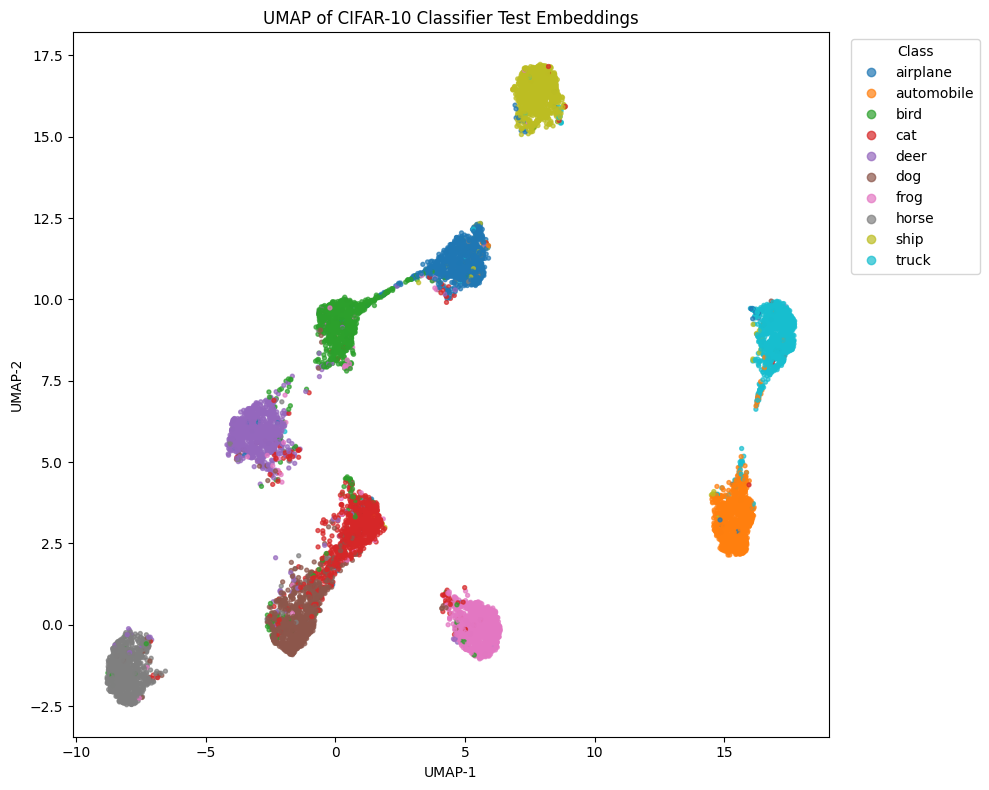

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=test_labels.numpy(),
    cmap="tab10",
    s=8,
    alpha=0.7,
)
ax.set_title("UMAP of CIFAR-10 Classifier Test Embeddings")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")

handles, _ = scatter.legend_elements(num=len(CIFAR10_CLASSES))
ax.legend(handles, CIFAR10_CLASSES, title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

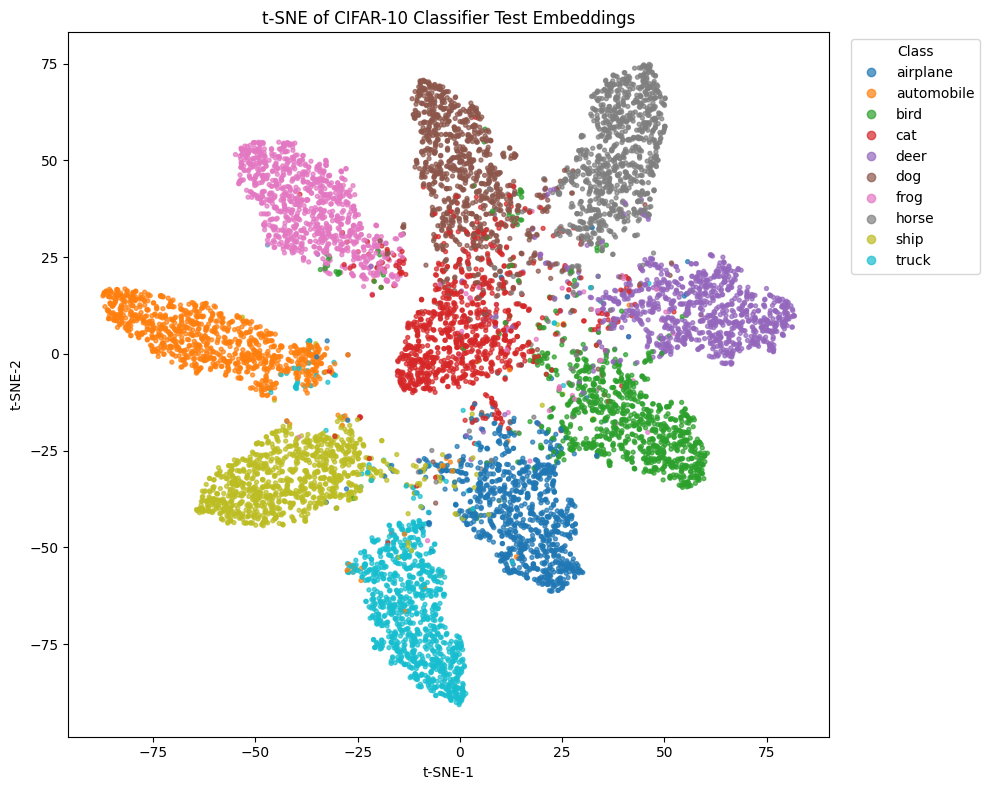

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    tsne_2d[:, 0],
    tsne_2d[:, 1],
    c=test_labels.numpy(),
    cmap="tab10",
    s=8,
    alpha=0.7,
)
ax.set_title("t-SNE of CIFAR-10 Classifier Test Embeddings")
ax.set_xlabel("t-SNE-1")
ax.set_ylabel("t-SNE-2")

handles, _ = scatter.legend_elements(num=len(CIFAR10_CLASSES))
ax.legend(handles, CIFAR10_CLASSES, title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Optional: inspect separation between two classes

Set `SELECTED_CLASSES` to two class ids if you want to focus on whether two groups are well separated under both UMAP and t-SNE.

/w/20252/wjcai/uq/manygp/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


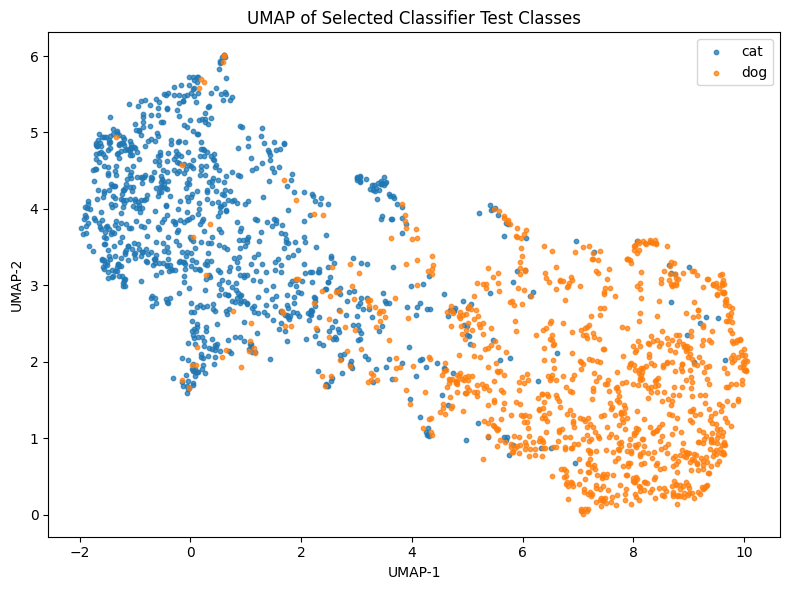

In [11]:
SELECTED_CLASSES = [3, 5]  # example: cat vs dog

mask = torch.isin(test_labels, torch.tensor(SELECTED_CLASSES))
subset_embeddings = test_embeddings[mask]
subset_labels = test_labels[mask]

subset_2d = umap.UMAP(
    n_neighbors=20,
    min_dist=0.05,
    metric="cosine",
    random_state=42,
).fit_transform(subset_embeddings.numpy())

fig, ax = plt.subplots(figsize=(8, 6))
for class_id in SELECTED_CLASSES:
    class_mask = subset_labels.numpy() == class_id
    ax.scatter(
        subset_2d[class_mask, 0],
        subset_2d[class_mask, 1],
        s=10,
        alpha=0.75,
        label=CIFAR10_CLASSES[class_id],
    )

ax.set_title("UMAP of Selected Classifier Test Classes")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend()
plt.tight_layout()
plt.show()

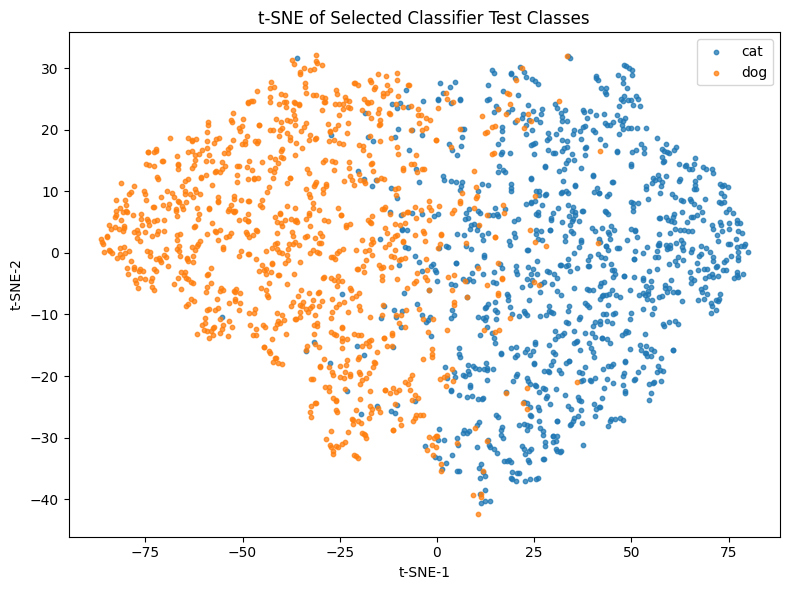

In [12]:
subset_tsne_2d = TSNE(
    n_components=2,
    perplexity=20,
    learning_rate="auto",
    init="pca",
    random_state=42,
).fit_transform(subset_embeddings.numpy())

fig, ax = plt.subplots(figsize=(8, 6))
for class_id in SELECTED_CLASSES:
    class_mask = subset_labels.numpy() == class_id
    ax.scatter(
        subset_tsne_2d[class_mask, 0],
        subset_tsne_2d[class_mask, 1],
        s=10,
        alpha=0.75,
        label=CIFAR10_CLASSES[class_id],
    )

ax.set_title("t-SNE of Selected Classifier Test Classes")
ax.set_xlabel("t-SNE-1")
ax.set_ylabel("t-SNE-2")
ax.legend()
plt.tight_layout()
plt.show()